<div style="display: flex; justify-content: center;">
  <h1 style="font-size: 40px;">Apprentissage supervisé</h1>
</div>





 <h1 style="font-size: 40px;">Classification:
 KNeighborsClassifier et
 DecisionTreeClassifier </h1>
    


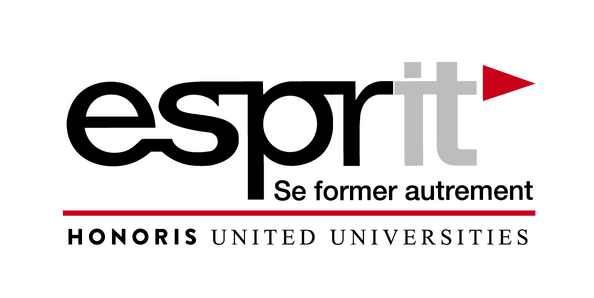
    

## Plan
1. Dataset : 🌦️ **Présentation du jeu de données météorologiques de Seattle** 🌦️
    * Chargement des données
    * Description statistique
    * Matrice de corrélation
    * Scattet Plot
    * Prétraitement des données
    * Division du dataset en train et test
2. Apprentissage supervisé : **Applications des modèles de classification**
    * Modèle 1 : K-Nearest Neighbors (KNN)
    * Modèle 2 : Arbre de Décision
    

### Importation des bibliothèques

In [5]:
import pandas as pd # une bibliothèque pour la manipulation et l'analyse de données
import numpy as np # une bibliothèque pour la manipulation des matrices
import matplotlib.pyplot as plt # une bibliothèque pour la création des graphiques
import seaborn as sns # une bibliothèque pour la visualisation de données
import warnings
from IPython.display import Image # une classe pour l'affichage d'images dans les notebooks Jupyter
from sklearn.preprocessing import LabelEncoder # une classe pour encoder des variables catégorielles
from sklearn.preprocessing import OneHotEncoder # une classe pour encoder des variables catégorielles
from sklearn.compose import ColumnTransformer # Une classe pour transformer des colonnes
from sklearn.preprocessing import StandardScaler # pour mettre à l’échelle vos caractéristiques numériques
# Importer les metriques
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')

### Objectifs du TP

1. Explorer une base de données et la préparer
2. Créer un `train_set` et un `test_set` avec la fonction `train_test_split()`
3. Appliquer 2 modèles de classification :
    * KNN
    * Decision tree
4. Valider un modèle avec la technique de `cross validation`
5. Améliorer un modèle en utilisant `GridSearchCV`

## Dataset : 🌦️ **Présentation du jeu de données météorologiques de Seattle** 🌦️

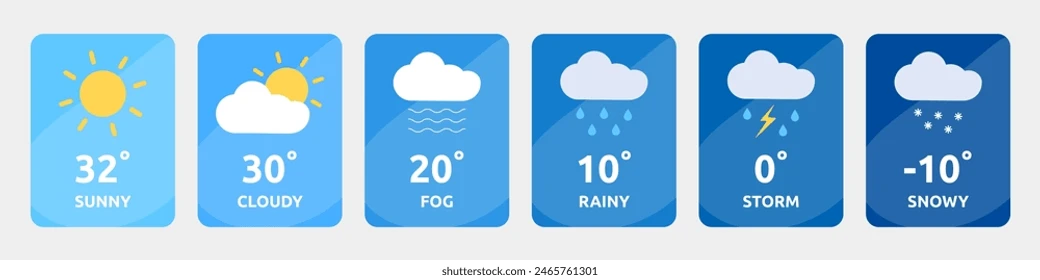

L'analyse du climat à Seattle consiste à comprendre diverses variables météorologiques enregistrées quotidiennement. Grâce au fichier *seattle-weather.csv*, nous pouvons explorer les tendances météorologiques, les changements saisonniers et prédire les conditions météorologiques futures à Seattle.  
Le jeu de données contient les caractéristiques suivantes :

🔍 **Aperçu du jeu de données** :

📅 **Date** : La date des relevés météorologiques.

☔ **Précipitations** : La quantité de précipitations (en mm) enregistrée ce jour-là.

🌡️ **Temp_max** : La température maximale (en degrés Celsius) enregistrée ce jour-là.

🌡️ **Temp_min** : La température minimale (en degrés Celsius) enregistrée ce jour-là.

💨 **Vent** : La vitesse du vent (en m/s) enregistrée ce jour-là.

🌦️ **Météo** : Le type de temps (ex : bruine, pluie).

### 1. Chargement et Exploration des Données
**Question :**  
- Chargez le fichier `seattle-weather.csv` dans un DataFrame et afficher les premières lignes du DataFrame.  
  Que pouvez-vous observer sur les colonnes de ce dataset ?


In [6]:
# Chargement et Exploration des Données
df = pd.read_csv('seattle-weather.csv')
print(df.head())

# Affichage des infos sur les colonnes
print(df.info())



         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB
None


### 2. Structure du Dataset
**Question :**  
- Affichez les colonnes et la taille de la Dataframe.


In [7]:
# Structure du Dataset
print( df.columns)



Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')


In [8]:
# taille du data
print( df.shape)



(1461, 6)


### 3. Données Manquantes
**Question :**  
- Vérifiez la présence de valeurs manquantes dans le DataFrame.  
  

In [9]:
# valeur nulle
print(df.isnull().sum())


date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


### 4. Statistiques Descriptives
**Question :**  
- Affichez les statistiques descriptives des variables numériques.  


In [10]:
# statistique data
print(df.describe())



       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.029432    16.439083     8.234771     3.241136
std         6.680194     7.349758     5.023004     1.437825
min         0.000000    -1.600000    -7.100000     0.400000
25%         0.000000    10.600000     4.400000     2.200000
50%         0.000000    15.600000     8.300000     3.000000
75%         2.800000    22.200000    12.200000     4.000000
max        55.900000    35.600000    18.300000     9.500000


**Question :**  
- Affichez également des statistiques sur les variables de type objet.  
  

In [11]:
# statistique data object

print(df.describe(include='object'))


              date weather
count         1461    1461
unique        1461       5
top     2012-01-01    rain
freq             1     641


### 5. Analyse de la Variable Cible
**Question :**  
- Affichez la répartition des valeurs de la variable `weather`.  
  

In [12]:
# Analyse de la Variable Cible
print(df['weather'].value_counts())

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


### 6. Suppression d’une Colonne
**Question :**  
-La colonne `date` du DataFrame est elle nécessaire pour l'analyse? Que faire dans ce cas ?
  

In [13]:
# ......... la colonne date
Non, elle nest  pas nécessaire 
donc ; on va supprimer la colonne avant lentraînement du modèle pour simplifier le dataset :


SyntaxError: invalid syntax (4240752242.py, line 2)

In [ ]:
df.drop('date', axis=1, inplace=True)

### 7. Encodage de la Variable Catégorielle
**Question :**  
- Encodez la variable `weather` en valeurs numériques en utilisant le LabelEncoder de scikit-learn.  
  **Indication :** Utilisez `LabelEncoder()` et appliquez-le à la colonne `weather` pour créer une nouvelle colonne `weather_encode`.

In [55]:
from sklearn.preprocessing import LabelEncoder
# à compléter
le = LabelEncoder()
df['weather_encode'] = le.fit_transform(df['weather'])


In [56]:
print(df[['weather', 'weather_encode']].head())


   weather  weather_encode
0  drizzle               0
1     rain               2
2     rain               2
3     rain               2
4     rain               2


### 8. Analyse de la Corrélation entre les Variables
**Question :**  
- Calculez et affichez la matrice de corrélation entre les variables numériques, à l'exception de la variable `weather`.

**NB:Une matrice de corrélation est un tableau qui affiche les coefficients de corrélation entre plusieurs variables d'un ensemble de données. Chaque élément de la matrice représente la correlation entre deux variables qui varie entre -1 et 1.**

  **compléter:**  
  1. Utilisez .......pour supprimer la colonne `weather` avant de calculer la corrélation.
  2. Utilisez la méthode ....... pour calculer la matrice de corrélation des variables restantes.
  3. Affichez la matrice sous forme de heatmap avec ......, en activant l'option ........ pour afficher les valeurs de corrélation dans chaque cellule.
  4. Commentez les résultats : quelles relations observe-t-on entre les variables ?

In [ ]:
#Supprimer la colonne weather
df_numeric = df.drop(['weather', 'weather_encode'], axis=1, errors='ignore')
# Calculer la matrice de corrélation
corr_matrix = df_numeric.corr()
# Afficher la matrice de corrélation

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables météorologiques")
plt.show()




**Astuce :**  
- Une corrélation proche de 1 indique une forte relation positive entre deux variables, tandis qu'une corrélation proche de -1 indique une forte relation négative.
- Une corrélation proche de 0 suggère qu'il n'y a pas de relation linéaire significative entre les variables.

**Remarque:**

**-Si certaines variables sont très corrélées, On peut en supprimer une pour éviter la redondance et améliorer l'efficacité du modèle.**

**-En analysant les corrélations, on peut identifier quelles variables influencent le plus la variable cible et éliminer celles qui sont inutiles.**

**-Une bonne visualisation des corrélations peux aider à mieux interpréter les données avant d'entrainer un modèle.**

### 9. Visualisation des Données
**Question :**  
- Créez un scatter plot pour visualiser les relations entre les différentes variables en utilisant `sns.pairplot()`.  
  **Indication :** Affichez les nuages de points avec la variable `weather` comme couleur (hue).

In [ ]:
#Afficher les nuages de points
sns.pairplot(df, hue='weather', palette='viridis')
plt.show()


Les nuages de points permettent d'examiner visuellement les corrélations entre les variables.

Observez si certaines classes de weather (par exemple, pluie, soleil, nuageux) forment des groupes distincts dans certains nuages de points. Cela peut vous donner des indications sur la facilité avec laquelle ces classes peuvent être séparées par un modèle de classification.

### 10. Prétraitement des Données
**Question :**  
- Séparez les données en deux ensembles : `X` (variables explicatives) et `y` (variable cible `weather_encode`).  
  

In [16]:
# Supprimer les colonnes inutiles


X = df.drop(['weather', 'weather_encode', 'date'], axis=1, errors='ignore')


In [19]:
# affichage X
print(X.head())
print(df.columns)


   precipitation  temp_max  temp_min  wind
0            0.0      12.8       5.0   4.7
1           10.9      10.6       2.8   4.5
2            0.8      11.7       7.2   2.3
3           20.3      12.2       5.6   4.7
4            1.3       8.9       2.8   6.1
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')


In [20]:
# affichage y
y = df['weather']
print(y.head())



0    drizzle
1       rain
2       rain
3       rain
4       rain
Name: weather, dtype: object


### 11. Séparation en Ensemble d’Entraînement et de Test
**Question :**  
- Divisez les données en ensembles d’entraînement et de test avec un ratio de 70/30.  
  **Indication :** Utilisez `train_test_split()` de scikit-learn.

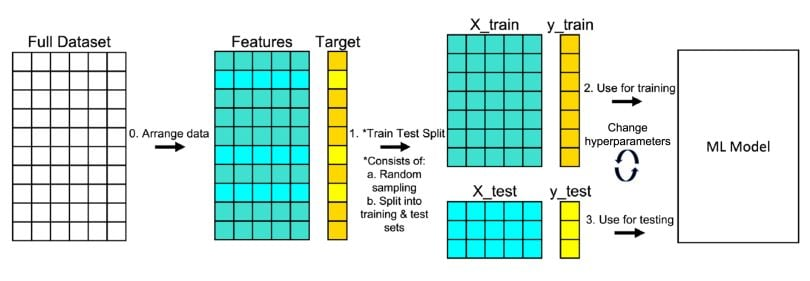


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Apprentissage supervisé : Applications des modèles de classification

## Modèle 1 : K-Nearest Neighbors (KNN)

Le modèle **K-Nearest Neighbors (KNN)** est un algorithme de classification basé sur la proximité des données. Il utilise les points de données les plus proches pour classer un nouvel exemple, en fonction de la majorité des classes de ses voisins.

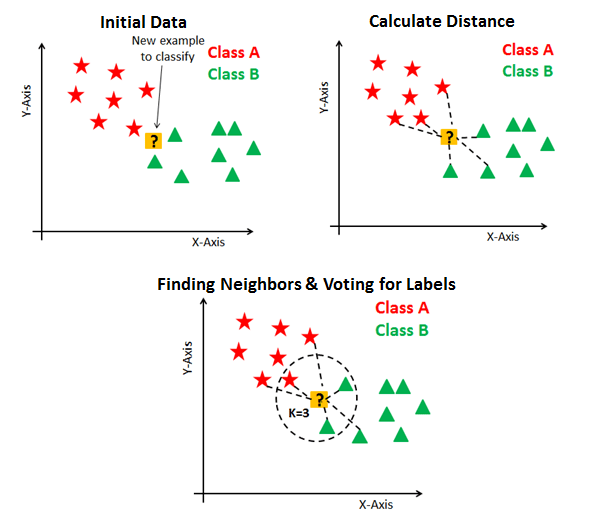

**Comment fonctionne KNN ?**
   Lorsque le modèle KNN reçoit un nouvel exemple à classer (ici un nouveau client), il va :
   - Calculer la distance (souvent **euclidienne**) entre ce point et tous les points d'entraînement.
   - Trouver les **k voisins les plus proches**.
   - Classer le point en fonction de la majorité des classes de ces voisins (par exemple, si la majorité des voisins sont des clients qui n'ont pas quitté, le modèle prédit que le nouveau client ne partira pas).

**Calcul de la distance euclidienne :**
   Pour chaque nouvelle observation à prédire, la distance euclidienne est calculée entre ce point et chaque point du jeu de données météorologiques d'entraînement. La formule de la distance euclidienne dans un espace à \(d\) dimensions est :

   $$ d(X, Y) = \sqrt{\sum_{i=1}^{d} (X_i - Y_i)^2} $$

   où \(X\) et \(Y\) représentent deux jours avec leurs caractéristiques météorologiques, et \(d\) est le nombre de dimensions (ou caractéristiques) utilisées dans le modèle.

   Par exemple, pour deux jours ayant les caractéristiques \(X\) et \(Y\) avec les valeurs de leurs **Temp_max**, **Temp_min**, **Precipitations**, **Vent**, etc., cette formule est utilisée pour calculer la distance entre eux. Plus la distance est petite, plus les conditions météorologiques de ces deux jours sont similaires.

### Normalisation des données

Le modèle KNN est simple mais puissant dans les problèmes de classification, notamment pour la prédiction des conditions météorologiques. Cependant, il est sensible à la qualité des données et nécessite généralement une **mise à l'échelle** des variables pour garantir des calculs de distance corrects, car certaines variables peuvent avoir des amplitudes très différentes (par exemple, **Precipitations** pourrait être en millimètres, tandis que **Temp_max** est en degrés Celsius).

La **normalisation des données** peut ainsi être nécessaire pour que chaque variable ait la même influence sur le calcul de la distance.

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()#instancier un StandardScaler
X_train =scaler.fit_transform(X_train)
X_test =  scaler.transform(X_test)

1. **Importation et initialisation du modèle KNN :**
   Vous pouvez importer le modèle **KNeighborsClassifier** de la bibliothèque scikit-learn. Lors de l'initialisation, le paramètre clé est **k**, le nombre de voisins que l'on souhaite prendre en compte pour faire la classification. Dans cet exemple, nous fixons initialement k à 5.

In [23]:
# KNeighborsClassifier avec n_neighbors = 5
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors=5)

In [24]:
# KNeighborsClassifier?
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)
print("10 premières prédictions :", y_pred[:10])

10 premières prédictions : ['sun' 'rain' 'rain' 'sun' 'rain' 'rain' 'sun' 'sun' 'rain' 'sun']


   - **k-neighbors (k)** : Ce paramètre détermine combien de voisins le modèle va prendre en compte pour effectuer une classification. Un **k** trop petit peut rendre le modèle sensible au bruit, tandis qu'un **k** trop grand peut lisser trop les décisions et rendre le modèle moins flexible. Ici, nous fixons **k = 5**, mais ce paramètre sera ajusté lors du réglage des hyperparamètres.

2. **Entraînement du modèle KNN** :
   Le modèle KNN est ensuite ajusté (ou "entraîné") sur le jeu de données d'entraînement. Cela signifie que le modèle va simplement stocker les données d'entraînement, car KNN est un **modèle basé sur les instances** (pas un modèle paramétrique), où aucune règle explicite n'est apprise lors de l'entraînement.

Compléter les ponitillés pour entrainer le modèle

In [25]:
# entrainer
KNN.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None



- **X_train_scaled** représente les caractéristiques **normalisées** des observations météorologiques (par exemple, **Temp_max**, **Temp_min**, **Precipitations**, **Vent**, etc.).
- **y_train** est la variable cible, qui dans ce cas est la colonne **Weather**, indiquant le type de météo (par exemple, bruine, pluie, etc.).

### Évaluation du modèle :
compléter les pointillets:

In [26]:
# calculer y_pred
y_pred = KNN.predict(X_test)

In [27]:
# affichage y_test[i], y_pred_knn[i]
print("Valeurs réelles (y_test) :", y_test.values) # y_test converti en np.ndarray pour l'affichage
print("Prédictions du modèle (y_pred) :", y_pred)# Afficher y_pred
score = accuracy_score(y_test, y_pred)
print(f"Score de précision du modèle : {score * 100:.2f}%")#Afficher le score du modèle

Valeurs réelles (y_test) : ['sun' 'rain' 'rain' 'sun' 'rain' 'rain' 'rain' 'sun' 'rain' 'sun' 'sun'
 'sun' 'rain' 'sun' 'fog' 'rain' 'sun' 'fog' 'fog' 'sun' 'rain' 'rain'
 'rain' 'sun' 'fog' 'rain' 'sun' 'sun' 'fog' 'sun' 'rain' 'sun' 'sun'
 'snow' 'sun' 'rain' 'rain' 'rain' 'rain' 'sun' 'rain' 'sun' 'fog' 'sun'
 'sun' 'rain' 'rain' 'sun' 'rain' 'sun' 'sun' 'rain' 'sun' 'rain' 'sun'
 'rain' 'rain' 'sun' 'rain' 'sun' 'rain' 'sun' 'snow' 'sun' 'sun'
 'drizzle' 'rain' 'sun' 'rain' 'rain' 'rain' 'fog' 'sun' 'rain' 'rain'
 'sun' 'rain' 'sun' 'rain' 'snow' 'rain' 'drizzle' 'rain' 'sun' 'rain'
 'sun' 'drizzle' 'rain' 'fog' 'rain' 'rain' 'sun' 'sun' 'rain' 'rain'
 'sun' 'sun' 'rain' 'sun' 'rain' 'sun' 'sun' 'rain' 'snow' 'rain' 'sun'
 'sun' 'rain' 'sun' 'rain' 'rain' 'sun' 'rain' 'rain' 'drizzle' 'fog'
 'sun' 'sun' 'sun' 'rain' 'rain' 'rain' 'rain' 'rain' 'rain' 'sun' 'sun'
 'sun' 'sun' 'sun' 'sun' 'sun' 'sun' 'sun' 'fog' 'sun' 'rain' 'rain'
 'rain' 'sun' 'drizzle' 'sun' 'rain' 'rain' 'drizzle

In [28]:
# Importer les metriques
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score, confusion_matrix, classification_report

 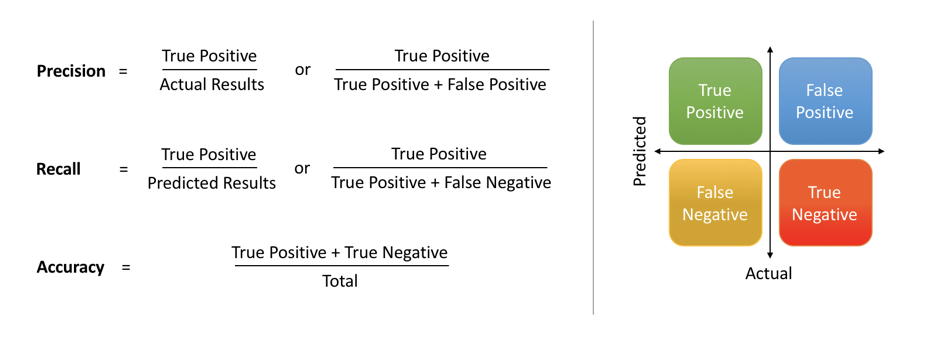

#### Matrice de confusion
Compléter les pointillés pour afficher la matrice de confusion et interpréter les résultats obtenues.

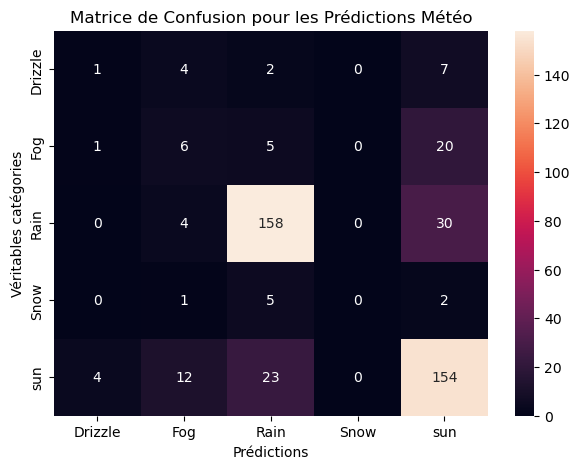

In [39]:
# Create a confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
# Visualiser la matrice de confusion avec un heatmap
plt.figure(figsize=(7, 5), dpi=100)
sns.heatmap(conf_matrix, annot=True, fmt="d",
            xticklabels=['Drizzle', 'Fog', 'Rain', 'Snow', 'sun'],
            yticklabels=['Drizzle', 'Fog', 'Rain', 'Snow', 'sun'])
plt.ylabel('Véritables catégories')
plt.xlabel('Prédictions')
plt.title('Matrice de Confusion pour les Prédictions Météo')
plt.show()


Compléter les pointillés pour afficher le rapport de classification et interpréter les résultats obtenues.

In [40]:
#Afficher le rapport de classification
print(classification_report(y_test, y_pred, target_names=['Drizzle', 'Fog', 'Rain', 'Snow', 'Sun']))

              precision    recall  f1-score   support

     Drizzle       0.17      0.07      0.10        14
         Fog       0.22      0.19      0.20        32
        Rain       0.82      0.82      0.82       192
        Snow       0.00      0.00      0.00         8
         Sun       0.72      0.80      0.76       193

    accuracy                           0.73       439
   macro avg       0.39      0.38      0.38       439
weighted avg       0.70      0.73      0.71       439



##### Validation croisée et réglage des hyperparamètres

##### Validation croisée
La **validation croisée** est une technique d’évaluation qui consiste à diviser le jeu de données en plusieurs sous-ensembles (appelés **folds**). Le modèle est entraîné sur certains de ces sous-ensembles et testé sur les autres. Cette rotation entre les sous-ensembles permet d’obtenir une estimation plus fiable des performances du modèle, réduisant les risques de sur-apprentissage ou de sous-apprentissage.

**Exemple** : Pour une validation croisée à 5 plis (5-fold cross-validation), les données sont divisées en 5 parties. Le modèle est entraîné sur 4 parties et testé sur la partie restante, et cela est répété 5 fois.

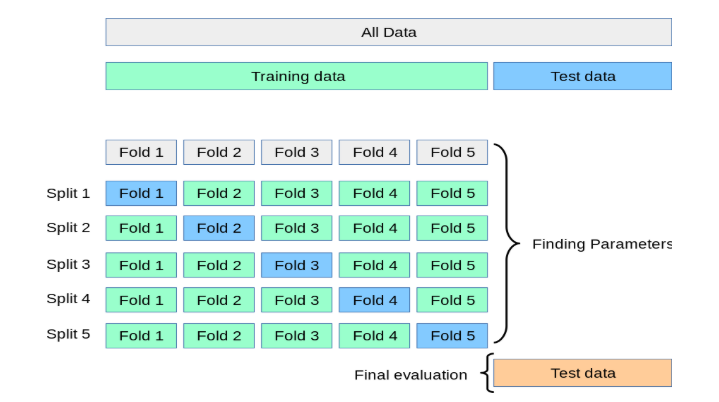

In [41]:
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': range(1, 20), 'metric':['euclidean', 'manhattan', 'minkowski'], 'weights':['uniform', 'distance']}
# Application de GridSearchCV avec validation croisée
grid_KNN = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_KNN.fit(X_train, y_train)
print("Meilleurs paramètres trouvés :", grid_KNN.best_params_)


Meilleurs paramètres trouvés : {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [42]:
# calcul de la nouvelle y_pred
Final_model = KNeighborsClassifier(**grid_KNN.best_params_)

In [43]:
Final_model

,n_neighbors,11
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [44]:
# Performance du modèle optimal
Final_model = grid_KNN.best_estimator_

In [45]:
Final_model

,n_neighbors,11
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


Les **hyperparamètres** (comme le nombre de voisins \(k\) pour KNN) influencent les performances du modèle, mais ne sont pas appris directement à partir des données. Pour trouver les meilleurs hyperparamètres, on utilise des techniques comme **GridSearchCV**, qui effectue une recherche sur plusieurs combinaisons d’hyperparamètres en utilisant la validation croisée.

In [46]:
# Meilleur k trouvé
best_k = grid_KNN.best_params_['n_neighbors']

In [47]:
#Final_model.fit(X_train, y_train)
print('train score = ', Final_model.score(X_train, y_train))
print('test score = ', Final_model.score(X_test, y_test))
print(f'Score du modèle KNN avec {best_k} voisins : {Final_model.score(X_test, y_test)}')


train score =  0.99706457925636
test score =  0.7585421412300684
Score du modèle KNN avec 11 voisins : 0.7585421412300684


In [50]:
y_pred_knn = Final_model.predict(X_test)# y_pred pour le modèle final
# Précision, rappel et F1-score pour KNN
print(classification_report(y_test, y_pred_knn, 
                            target_names=['Drizzle', 'Fog', 'Rain', 'Snow', 'Sun']))

              precision    recall  f1-score   support

     Drizzle       0.33      0.07      0.12        14
         Fog       0.14      0.03      0.05        32
        Rain       0.88      0.84      0.86       192
        Snow       1.00      0.12      0.22         8
         Sun       0.69      0.88      0.77       193

    accuracy                           0.76       439
   macro avg       0.61      0.39      0.40       439
weighted avg       0.73      0.76      0.73       439



**Questions:**
Interpréter les résultats obtennues (le score d'entrainement et le score du test)? Est ce qu'on est dans le cas de surapprentissage?

#### Application :

 Soit la base de donnée contient des données météorologiques pour trois observations, organisées en colonnes représentant différentes mesures climatiques.

## Structure des données

| Colonne         | Description                                                                 | Exemple de valeurs |
|------------------|-----------------------------------------------------------------------------|--------------------|
| **precipitation** | Quantité de précipitations (en millimètres)                                | 0.0, 0.5, 0.2      |
| **temp_max**      | Température maximale enregistrée (en degrés Celsius)                      | 12.2, 15.3, 18.9   |
| **temp_min**      | Température minimale enregistrée (en degrés Celsius)                      | 5.6, 8.3, 10.2     |
| **wind**          | Vitesse du vent mesurée (en mètres par seconde)                           | 4.7, 2.6, 3.9      |

## Exemple de contenu

Voici les données représentées sous forme de tableau :

| precipitation | temp_max | temp_min | wind |
|---------------|----------|----------|------|
| 0.0           | 12.2     | 5.6      | 4.7  |
| 0.5           | 15.3     | 8.3      | 2.6  |
| 0.2           | 18.9     | 10.2     | 3.9  |

En utilisant le modèle final basé sur l'algorithme KNN et les différentes mesures climatiques fournies dans la base de données, prédire la variable cible weather, en complétant les pointillés

In [58]:
#df.columns
print(y_train[:10])

1452    rain
762     rain
932      sun
435     rain
629      sun
1210    rain
1118    rain
1084    rain
158     rain
967      sun
Name: weather, dtype: object


In [61]:
# 1. Création du DataFrame avec les données fournies
nouvelles_donnees_meteo = pd.DataFrame([
    [0.0, 12.2, 5.6, 4.7],
    [0.5, 15.3, 8.3, 2.6],
    [0.2, 18.9, 10.2, 3.9]
], columns=['precipitation', 'temp_max', 'temp_min', 'wind'])

# 2. Mise à l'échelle (Scaling) des données
nouvelles_donnees_meteo_scaled = scaler.transform(nouvelles_donnees_meteo)

# 3. Prédiction avec le modèle KNN
predictions_meteo = KNN.predict(nouvelles_donnees_meteo_scaled)

# 4. Conversion des codes numériques en noms de météo (ex: 'sun', 'rain')
labels_meteo = le.inverse_transform(predictions_meteo)

print("Prédictions météo :", labels_meteo)

NotFittedError: This LabelEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Modèle 2 : Arbre de Décision

L'algorithme construit un arbre basé sur des critères comme l'entropie ou l'indice de Gini pour déterminer les facteurs les plus influents dans la décision du type de météo (**Weather**) à prévoir (par exemple, bruine, pluie, etc.).

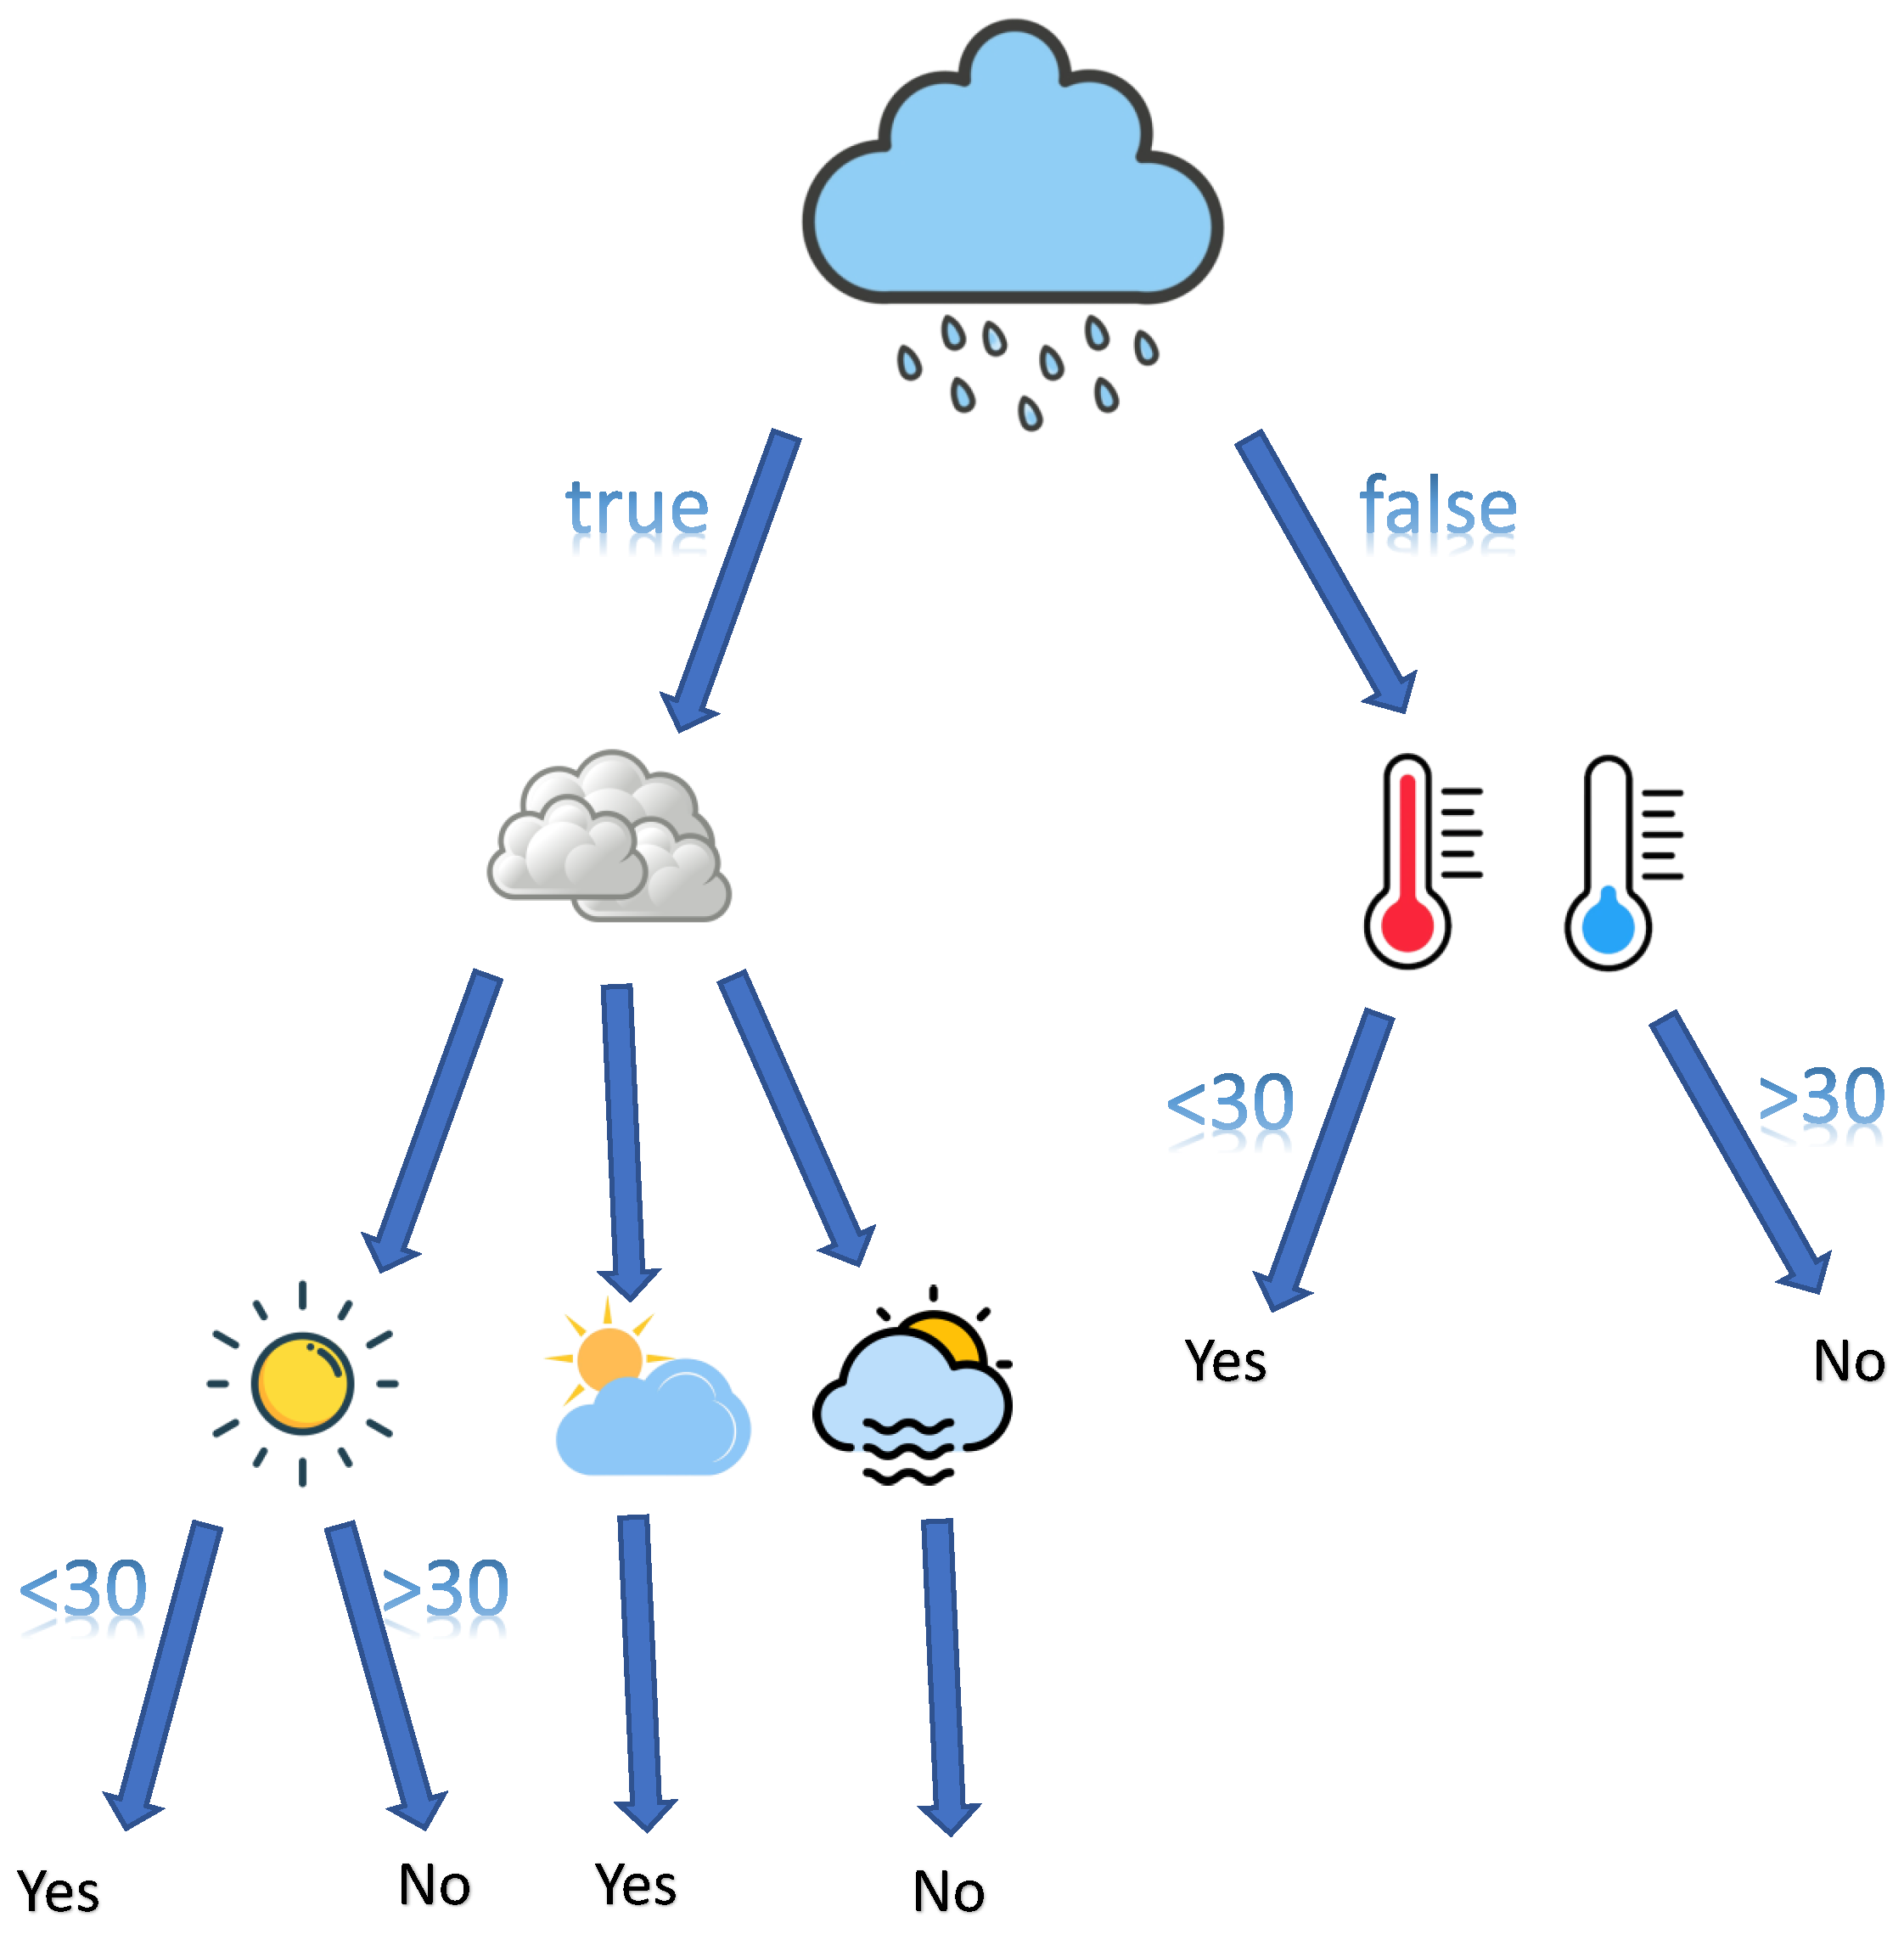

Les arbres de décision n'utilisent pas de mesures de distance pour classer les données. Ils se basent sur des critères comme **l'entropie** ou **l'indice de Gini** pour découper l'espace des caractéristiques. Cela signifie que les valeurs absolues des caractéristiques n’ont pas d’impact sur la manière dont l’arbre prend des décisions.

$$\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2$$
Où :

* $C$ est le nombre de classes.
* $p_i$ est la proportion de la classe $i$ dans l'ensemble de données, $p_i = \frac{n_i}{N}$.


**Pas besoin de normalisation :** Les arbres de décision ne sont pas sensibles aux échelles des caractéristiques, car ils ne comparent pas directement les valeurs entre elles pour prendre des décisions.

### Question 1 : Classification avec Arbre de Décision  
- Divisez vos données en un ensemble d'entraînement et un ensemble de test, avec 30% des données réservées pour le test. Assurez-vous que cette division est reproductible.  

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Initialisation du modèle d'arbre de décision

L'initialisation du modèle d'arbre de décision consiste à créer une instance de l'algorithme et à l'ajuster (l'entraîner) sur les données d'entraînement.

### Question 2 : Création d'un Modèle de Classification  
- Créez un modèle d'arbre de décision pour classer vos données. Utilisez le critère de Gini pour mesurer l'impureté des nœuds et limitez la profondeur maximale de l'arbre à 5.  

In [63]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

**Ajustement (fit)** : Le modèle est ensuite ajusté aux données d'entraînement. L'algorithme utilise les caractéristiques (features) des données pour apprendre des règles de décision en découpant l'espace de caractéristiques de façon récursive.

### Question 3 : Entraînement du Modèle  
- Entraînez le modèle d'arbre de décision sur les données d'entraînement.

In [64]:
# Entraînement du Modèle
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**Création de l'arbre** :

Durant l'ajustement, le modèle divise les données à chaque nœud selon les critères choisis (Gini, entropie), créant ainsi une structure d'arbre où chaque branche représente une décision, et chaque feuille représente une classe de sortie (par exemple, le type de météo, comme bruine ou pluie).

L'entraînement d'un arbre de décision permet donc au modèle d'apprendre les relations entre les variables d'entrée et la classe à prédire, en créant des règles qui optimisent la classification des échantillons de données.

### Question 4 : Création et Entraînement d’un Arbre de Décision  
- Initialisez un nouveau modèle d'arbre de décision sans définir de paramètres spécifiques, puis entraînez-le sur les données d'entraînement.  

In [65]:
from sklearn.tree import DecisionTreeClassifier

# Initialisation du modèle sans paramètres spécifiques
tree = DecisionTreeClassifier()

# Entraînement du modèle sur les données d'entraînement
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**Évaluation du modèle :**

### Question 5 : Prédiction sur l’Ensemble de Test  
- Utilisez le modèle d'arbre de décision entraîné pour prédire les classes de l'ensemble de test.

In [66]:
# calculer y_pred
y_pred = tree.predict(X_test)

### Question 6 : Évaluation des Prédictions  
- Affichez les valeurs réelles des classes (`y_test`) et les valeurs prédites par le modèle (`y_pred`). Ensuite, évaluez les performances du modèle en calculant son score (précision) sur l'ensemble de test.  

In [67]:
# affichage y_test[i], y_pred_tree[i]
print("Valeurs réelles (y_test) :", np.array(y_test)) # y_test converti en np.ndarray pour l'affichage
print("Valeurs prédites (y_pred) :", y_pred)
print("Score de précision sur l'ensemble de test :", tree.score(X_test, y_test)) # score sur l'ensemble de test

Valeurs réelles (y_test) : [4 2 2 4 2 2 2 4 2 4 4 4 2 4 1 2 4 1 1 4 2 2 2 4 1 2 4 4 1 4 2 4 4 3 4 2 2
 2 2 4 2 4 1 4 4 2 2 4 2 4 4 2 4 2 4 2 2 4 2 4 2 4 3 4 4 0 2 4 2 2 2 1 4 2
 2 4 2 4 2 3 2 0 2 4 2 4 0 2 1 2 2 4 4 2 2 4 4 2 4 2 4 4 2 3 2 4 4 2 4 2 2
 4 2 2 0 1 4 4 4 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 1 4 2 2 2 4 0 4 2 2 0 1 4 2
 4 4 2 4 4 4 2 2 1 4 2 2 4 4 2 4 4 2 2 4 4 4 2 2 1 4 2 2 4 4 4 2 4 4 4 2 2
 2 2 2 4 4 0 1 4 2 1 4 1 2 3 2 2 4 0 2 4 2 2 4 2 4 2 4 4 4 2 4 4 4 2 4 2 4
 4 4 1 2 4 2 4 2 4 2 4 4 2 4 4 4 0 1 3 2 4 3 4 4 4 4 2 2 2 2 2 1 4 1 2 4 2
 2 2 2 2 2 2 1 2 1 1 4 4 4 4 2 4 4 2 3 4 4 1 2 4 4 4 4 2 4 4 2 1 2 4 1 2 2
 4 2 2 2 2 2 2 2 2 2 2 0 4 4 2 2 2 4 2 4 4 2 4 4 2 2 2 4 4 2 2 0 4 4 4 2 2
 2 4 4 2 2 2 2 2 4 2 2 4 2 1 2 2 2 4 4 1 2 4 2 4 1 4 1 4 4 4 2 2 2 4 4 4 4
 2 2 2 2 2 2 2 2 2 2 2 4 1 4 2 2 2 4 4 2 2 4 4 4 2 4 4 4 2 2 2 4 4 0 4 2 4
 4 4 4 4 4 4 4 4 4 2 2 4 4 4 4 0 4 1 2 4 4 2 4 2 2 4 4 2 2 2 2 0]
Valeurs prédites (y_pred) : [4 2 1 0 2 2 4 4 2 0 4 4 2 4 1 2 4 2 4 4 2 4 2 4 4 2 4

### Question 7 : Matrice de Confusion  
- Calculez et visualisez la matrice de confusion pour évaluer la qualité des prédictions du modèle. Utilisez un heatmap pour représenter graphiquement la matrice, avec les catégories `['Rain', 'Sun', 'Fog', 'Drizzle', 'Snow']` comme étiquettes pour les axes.  

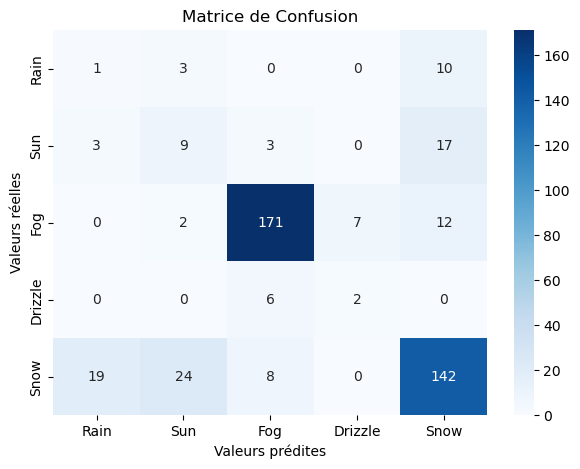

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Calcul de la matrice de confusion
# On compare les vraies étiquettes (y_test) aux prédictions (y_pred)
labels = ['Rain', 'Sun', 'Fog', 'Drizzle', 'Snow']
cm = confusion_matrix(y_test, y_pred)

# 2. Visualiser la matrice de confusion avec un heatmap
plt.figure(figsize=(7, 5), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Matrice de Confusion')
plt.xlabel('Valeurs prédites')
plt.ylabel('Valeurs réelles')
plt.show()

### Question 8 : Rapport de Classification  
- Affichez un rapport détaillé des performances du modèle. Ce rapport doit inclure des métriques comme la précision (precision), le rappel (recall) et le score F1 pour chaque classe.  

In [1]:
# Afficher le rapport de classification
from sklearn.metrics import classification_report

# Définition des noms de classes pour plus de clarté
target_names = ['Rain', 'Sun', 'Fog', 'Drizzle', 'Snow']

# Afficher le rapport de classification
print(classification_report(y_test, y_pred))


NameError: name 'y_test' is not defined

### Question 9 : Visualisation de l’Arbre de Décision  
- Visualisez l’arbre de décision entraîné pour mieux comprendre son fonctionnement. Assurez-vous que :  
  1. Les nœuds sont colorés en fonction de la classe majoritaire qu’ils représentent.  
  2. Les noms des caractéristiques (features) et des classes sont affichés clairement.  
  3. La figure est suffisamment grande pour afficher l’arbre sans chevauchement.  
  4. Enregistrez la figure au format PNG sous le nom `tree_model.png`.  

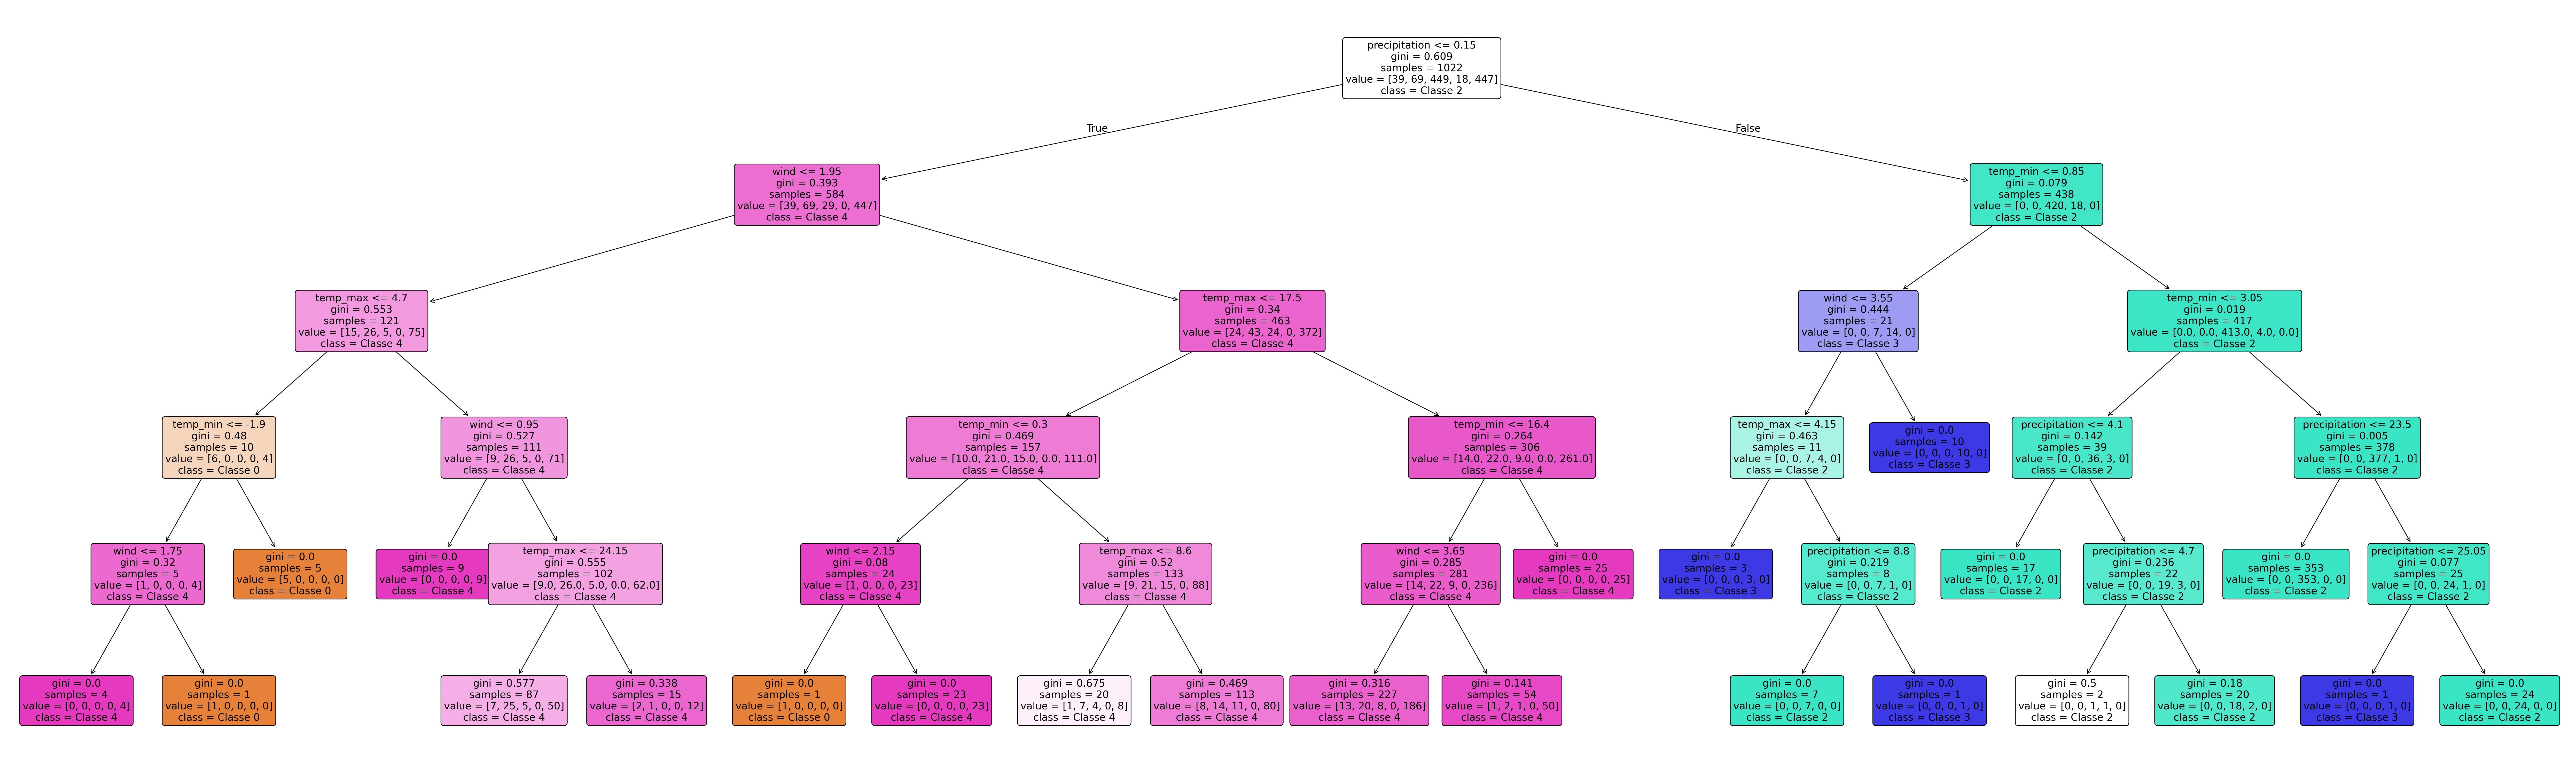

In [70]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualisation de l'arbre de décision
plt.figure(figsize=(50,15), dpi = 200)  # Augmenter la taille de la figure
plot_tree(model,
          filled=True,
          feature_names=X_train.columns,  # Noms des caractéristiques
          class_names=["Classe 0", "Classe 1", "Classe 2", "Classe 3", "Classe 4"],  # Noms des classes
          rounded=True,
          fontsize=14)  # Augmenter la taille de la police

plt.tight_layout()
plt.savefig("tree_model.png", dpi = 200)
plt.show()


### Question 10 : Recherche des Hyperparamètres Optimaux  
- Utilisez la recherche par grille (GridSearchCV) pour optimiser l'hyperparamètre `max_depth` de l'arbre de décision. Appliquez une validation croisée à 5 plis et affichez le meilleur paramètre trouvé pour `max_depth`.  

In [71]:
from sklearn.model_selection import GridSearchCV

# 1. Définir la plage de valeurs à tester pour max_depth (ex: de 1 à 20)
param_grid_tree = {'max_depth': np.arange(1, 21)}

# 2. Configurer GridSearchCV avec une validation croisée à 5 plis (cv=5)
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5)

# 3. Exécuter la recherche sur les données d'entraînement
grid_tree.fit(X_train, y_train)

# 4. Afficher le meilleur paramètre trouvé
print("Meilleure profondeur (max_depth) :", grid_tree.best_params_)

Meilleure profondeur (max_depth) : {'max_depth': np.int64(4)}


### Question 11 : Utilisation de la Profondeur Optimale et Visualisation de l'Arbre  
- Utilisez la profondeur optimale trouvée précédemment par GridSearchCV pour initialiser un modèle d'arbre de décision. Entraînez ce modèle sur les données d'entraînement et visualisez l'arbre résultant. Assurez-vous que :  
  1. L'arbre est visualisé avec les noms des caractéristiques et des classes.  
  2. La taille de la figure est suffisamment grande pour bien afficher l'arbre.  
  3. L'arbre est sauvegardé en tant qu'image au format PNG sous le nom `tree_optimal_model.png`.  

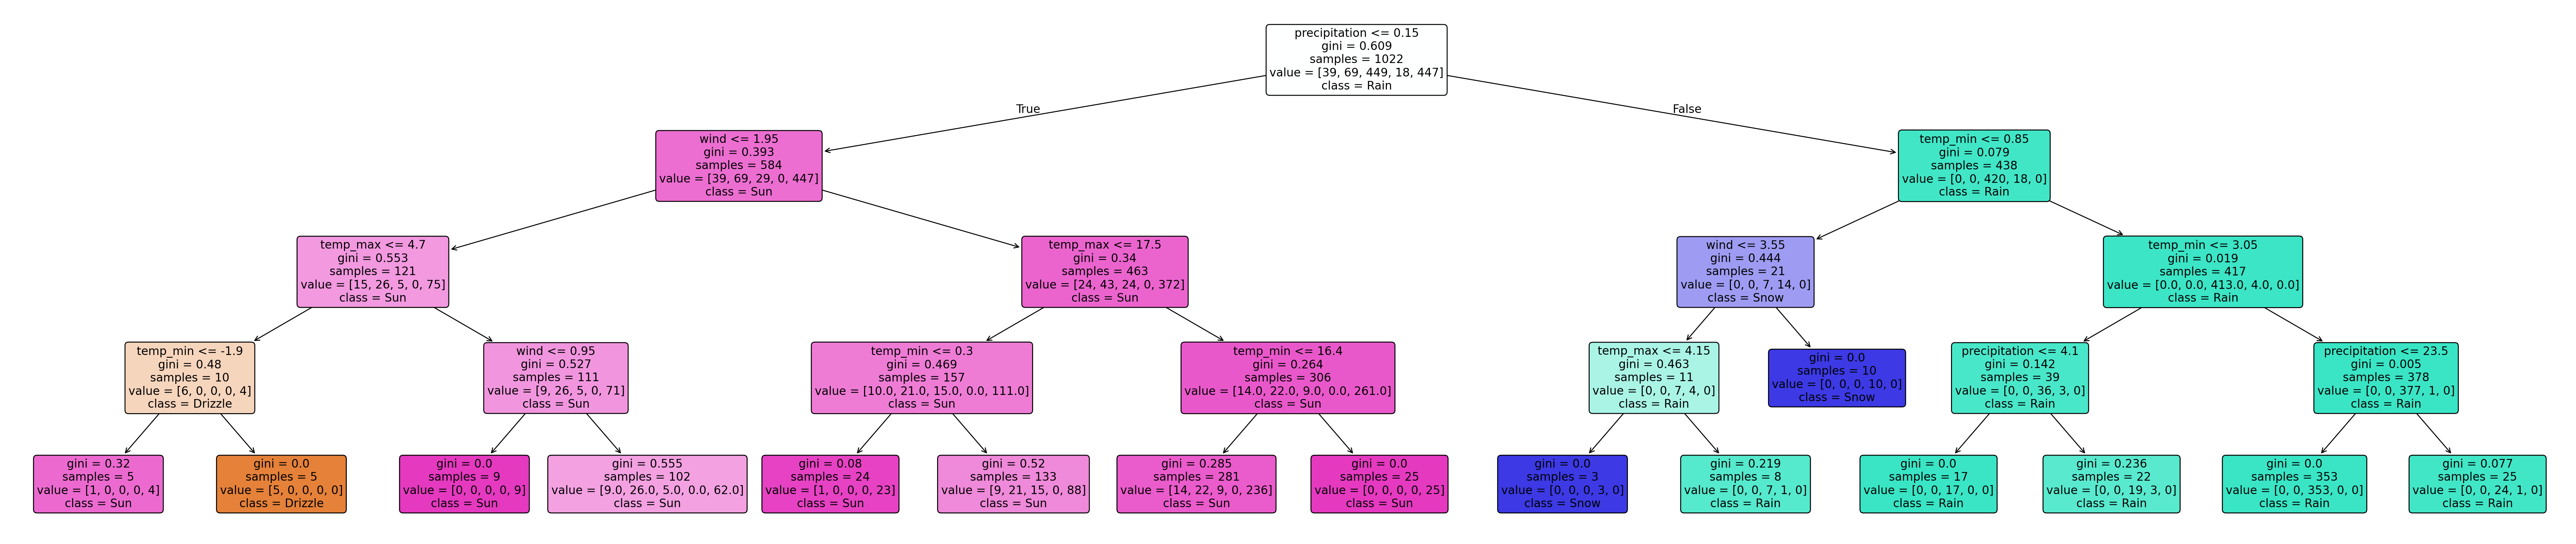

In [72]:
# Utiliser la profondeur optimale trouvée par GridSearchCV
optimal_depth = 4  # Supposons que GridSearchCV ait renvoyé 4

# Initialisation du modèle avec la profondeur optimale
# On ajoute random_state pour la reproductibilité
optimal_tree = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

# Entraîner à nouveau le modèle avec les données d'entraînement
optimal_tree.fit(X_train, y_train)

# Visualiser l'arbre avec plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Taille très large (48,10) pour garantir qu'aucune boîte ne se chevauche
plt.figure(figsize=(48, 10), dpi=200) 

plot_tree(optimal_tree,
          filled=True,
          feature_names=X_train.columns, 
          # Remplace par les vrais noms de ton LabelEncoder si nécessaire
          class_names=["Drizzle", "Fog", "Rain", "Snow", "Sun"], 
          rounded=True,
          fontsize=12)

# Sauvegarde de haute qualité
plt.savefig("tree_optimal_model.png", dpi=200, bbox_inches='tight')
plt.show()

### Question 12 : Importances des Variables  
- Calculez et affichez l'importance de chaque caractéristique (feature) dans l'arbre de décision optimisé. Ne montrez que les caractéristiques dont l'importance est différente de zéro.  

In [73]:
# features importances
# Affichage des importances des variables
for var, importance in zip(df.columns, optimal_tree.feature_importances_):
    # On ne garde que les caractéristiques ayant un impact (importance > 0)
    if importance > 0:
        print(f"{var} = {importance:.4f}")

precipitation = 0.8875
temp_max = 0.0246
temp_min = 0.0599
wind = 0.0280


### Question 13 : Visualisation des Importances des Caractéristiques  
- Créez une fonction pour afficher les importances des caractéristiques d'un modèle d'arbre de décision. La fonction doit afficher un graphique en barres horizontales où chaque barre représente l'importance d'une caractéristique dans la prédiction du modèle.  
- Utilisez cette fonction pour afficher les importances des caractéristiques du modèle optimisé `optimal_tree`.  


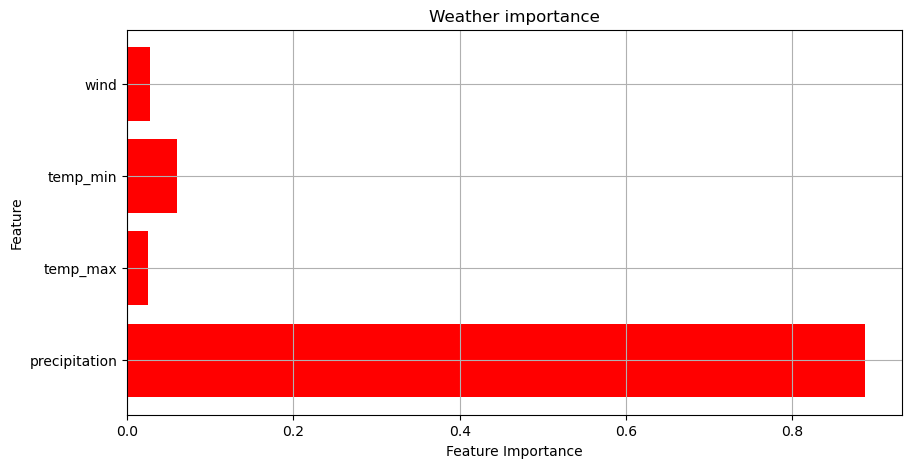

In [74]:
def weather_feature_importances_plot(model, features):
    """Plots feature importances for a given model.

    Args:
        model: The trained model.
        features: The list of features used by the model.
    """
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(features)), model.feature_importances_, align='center', color='red')
    plt.yticks(np.arange(len(features)), features)
    plt.title('Weather importance')
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.grid(True)

# Assuming X_train contains the features used for training
weather_feature_importances_plot(optimal_tree, X_train.columns)
plt.show()

**Remarque:
Le feature importance est une technique en machine learnning qui permet d'évaluer quelles variables influencent le plus les prédictions d'un modèle:**

**-Eliminer les variables non pertinentes permet d'éviter le bruit et d'améliorer la généralisation du modèle.**

**-Un modèle avec moins de variables inutiles est plus efficace et rapide.**

**-Un modèle avec trop de variables peut apprendre des relations spécifiques aux données d'entraînement et ne pas bien généraliser aux nouvelles données.**

**-Cette analyse permet de choisir les variables les plus influentes et éliminer celles qui n'apportent
pas d'information.**

### Question 14 : Exportation de l'Arbre de Décision sous forme de Texte  
- Affichez une représentation textuelle de l'arbre de décision optimisé, en incluant les poids des caractéristiques utilisées dans chaque décision. Utilisez la fonction `export_text` de `sklearn.tree`.

In [75]:
from sklearn.tree import export_text
print(export_text(optimal_tree,feature_names=X.columns,show_weights=True ))

|--- precipitation <= 0.15
|   |--- wind <= 1.95
|   |   |--- temp_max <= 4.70
|   |   |   |--- temp_min <= -1.90
|   |   |   |   |--- weights: [1.00, 0.00, 0.00, 0.00, 4.00] class: 4
|   |   |   |--- temp_min >  -1.90
|   |   |   |   |--- weights: [5.00, 0.00, 0.00, 0.00, 0.00] class: 0
|   |   |--- temp_max >  4.70
|   |   |   |--- wind <= 0.95
|   |   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 9.00] class: 4
|   |   |   |--- wind >  0.95
|   |   |   |   |--- weights: [9.00, 26.00, 5.00, 0.00, 62.00] class: 4
|   |--- wind >  1.95
|   |   |--- temp_max <= 17.50
|   |   |   |--- temp_min <= 0.30
|   |   |   |   |--- weights: [1.00, 0.00, 0.00, 0.00, 23.00] class: 4
|   |   |   |--- temp_min >  0.30
|   |   |   |   |--- weights: [9.00, 21.00, 15.00, 0.00, 88.00] class: 4
|   |   |--- temp_max >  17.50
|   |   |   |--- temp_min <= 16.40
|   |   |   |   |--- weights: [14.00, 22.00, 9.00, 0.00, 236.00] class: 4
|   |   |   |--- temp_min >  16.40
|   |   |   |   |--- weights: [0.00, 0.

In [76]:
# 1. Calculer les prédictions sur l'ensemble de test avec le modèle optimal
y_pred_tree = optimal_tree.predict(X_test)

# 2. Afficher le rapport de classification détaillé
# On compare les vraies valeurs (y_test) aux prédictions (y_pred_tree)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00        32
           2       0.97      0.91      0.94       192
           3       0.60      0.38      0.46         8
           4       0.76      1.00      0.86       193

    accuracy                           0.85       439
   macro avg       0.47      0.46      0.45       439
weighted avg       0.77      0.85      0.80       439





### Comparaison des Modèles

**Tableau Comparatif des Résultats** :

| Modèle               | Précision (macro avg) | Précision (weighted avg) | Rappel (macro avg) | Rappel (weighted avg) | F1-Score (macro avg) | F1-Score (weighted avg) |
|----------------------|-----------------------|--------------------------|--------------------|-----------------------|----------------------|-------------------------|
| KNN                  | 61.00%                | 73.00%                   | 39.00%             | 76.00%                | 40.00%               | 73.00%                  |
| Arbre de décision    | 45.00%                | 76.00%                   | 47.00%             | 74.00%                | 46.00%               | 75.00%                  |

---


### Conclusion

1. Analysez les résultats de performance.
2. Identifiez le meilleur modèle selon les métriques choisies (par exemple, AUC).
3. Discutez des avantages et inconvénients de chaque modèle dans le cadre de la prédiction du churn.

---

Ce TP vous guide à travers les étapes clés de l'analyse d'un dataset de churn, de la **préparation des données** à l'**optimisation des modèles**, tout en vous permettant de comparer deux algorithmes de classification supervisée populaires : KNN et arbre de décision.

**Travail à rendre**

L'objectif de ce travail est de comprendre et d'apliquer le One Hot Encoding, d'analyser l'impact de l'encodage sur la matrice de corrélation et d'adapter la base de données en fonctions des obsérvations.

**Partie 1**:

1.1) Appliquer le one-Hot Encoding au lieu du label encoder sur la meme base de données. Justifier l'utilisation de cet encodage.

1.2) Combien de colonnes supplémentaire sont t'il crée.
Comparer les avantages et les inconvénients du ONE-HotEncoding par rapport au Label Encoding.

1.3) Comment résoudre le problème d'affichage des matrices de confusion (pour les deux modèles) dans ce cas .

1.4) Comparez la précision du modèle dans les deux cas. Que constatez-vous?

**Partie 2:**

2.1) A partir de la matrice de corrélation  obtenue avec le One Hot encoding identifier les colonnes les plus corréllées.

2.2 ) Supprimer une des colonnes qui pourrait etre redondante.

2.3) Comparer les scores des modèles avant et après la modification

**Partie 3:**

3.1) Affichez l'importance des features pour les deux modèles.

3.2) Identifiez les variables ayant une importance très faible. Sont elles les meme que celle ayant une faible corrélation ?

3.3) Supprimez les variables peu importantes et réentrainez les modèles. Comparez les performances avant et après supression.

3.4) Quels conclusion tirez vous sur l'importance de bien encoder et préparer les données.
